# Actividad 5: Visualización de Resultados
**Equipo 74:**

*   Diana Jimena López Nájera
*   Marcelo Ismael López Verdugo
*   Salma Alejandra Macías Rosas
*   Dario Maximiliano Mendoza Orozco

---
## 1. Definición del proceso de validación cruzada
Para evaluar nuestro modelo de predicción de comportamiento de compra de manera robusta, implementaremos una validación cruzada de tipo **k-fold**.

**Argumentación del valor "k":**
Dado que estamos procesando un volumen masivo de datos (Big Data) proveniente de un comercio electrónico, seleccionar el estándar de la literatura ($k=10$) generaría costos computacionales y de memoria excesivos, con riesgo de colapso en el clúster. Por lo tanto, **definimos $k=3$**.
Esta elección garantiza:
1. **Representatividad:** Cada pliegue de entrenamiento contendrá aproximadamente el 66.6% de la muestra, y el de prueba el 33.3%, volúmenes estadísticamente suficientes para representar los patrones de la población $P$.
2. **Eficiencia:** Permite evaluar la variabilidad del modelo en un tiempo de ejecución viable, mitigando el riesgo de sobrecarga computacional.

In [1]:
# ==============================================================================
# IMPORTACIONES Y PREPARACIÓN DE DATOS (Basado en el código base del equipo)
# ==============================================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, lit, desc, hour, dayofweek, rand
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Iniciar SparkSession
spark = SparkSession.builder \
    .appName("Actividad5_Visualizacion_Eq74") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

# 2. Carga de datos
#file_path = "/content/drive/MyDrive/Big Data/2019-Oct.csv" # Ruta Colab
file_path="../datasets/2019-Oct.csv" # Ruta local
df = spark.read.option("header", True).option("inferSchema", True).csv(file_path)

# 3. Limpieza y preparación
df_clean = df.dropna(subset=["category_code", "brand", "price"])
df_clean = df_clean.withColumn("weekhour", dayofweek(col("event_time")) + hour(col("event_time")) / 24)

# 4. Agrupación de alta cardinalidad (Top 10 para brand y category)
cols_to_group = ["category_code", "brand"]
for col_name in cols_to_group:
    top_values = [row[col_name] for row in df_clean.groupBy(col_name)
                                              .count()
                                              .orderBy(desc("count"))
                                              .limit(10)
                                              .select(col_name)
                                              .collect()]

    grouped_col = f"{col_name}_grouped"
    df_clean = df_clean.withColumn(
        grouped_col,
        when(col(col_name).isin(top_values), col(col_name)).otherwise(lit("other"))
    )

# 5. Definición de la variable objetivo
df_clean = df_clean.withColumn("compro", when(col("event_type") == "purchase", 1.0).otherwise(0.0))

# 6. Construcción de la muestra representativa M
M = df_clean.sample(fraction=0.10, seed=42)

print(f"Preparación finalizada. Tamaño de la muestra M: {M.count():,} registros.")

Preparación finalizada. Tamaño de la muestra M: 2,654,763 registros.


## 2. Construcción de los "k-folds"
Para poblar los particionamientos, inyectaremos de forma pseudoaleatoria un identificador numérico (del 0 al $k-1$) a cada registro de nuestra muestra $M$. Al utilizar la función estocástica de PySpark junto a una semilla (`seed`), garantizamos que los registros se distribuyan respetando el muestreo original, previniendo sesgos en la concentración de clases.

In [2]:
k = 3

# Asignar a cada registro un 'fold' de forma aleatoria (0, 1 o 2)
M_folds = M.withColumn("fold", (rand(seed=42) * k).cast("int"))

print(f"Distribución de registros por Fold (Verificación de balanceo para k={k}):")
M_folds.groupBy("fold").count().orderBy("fold").show()

Distribución de registros por Fold (Verificación de balanceo para k=3):
+----+------+
|fold| count|
+----+------+
|   0|884971|
|   1|883825|
|   2|885967|
+----+------+



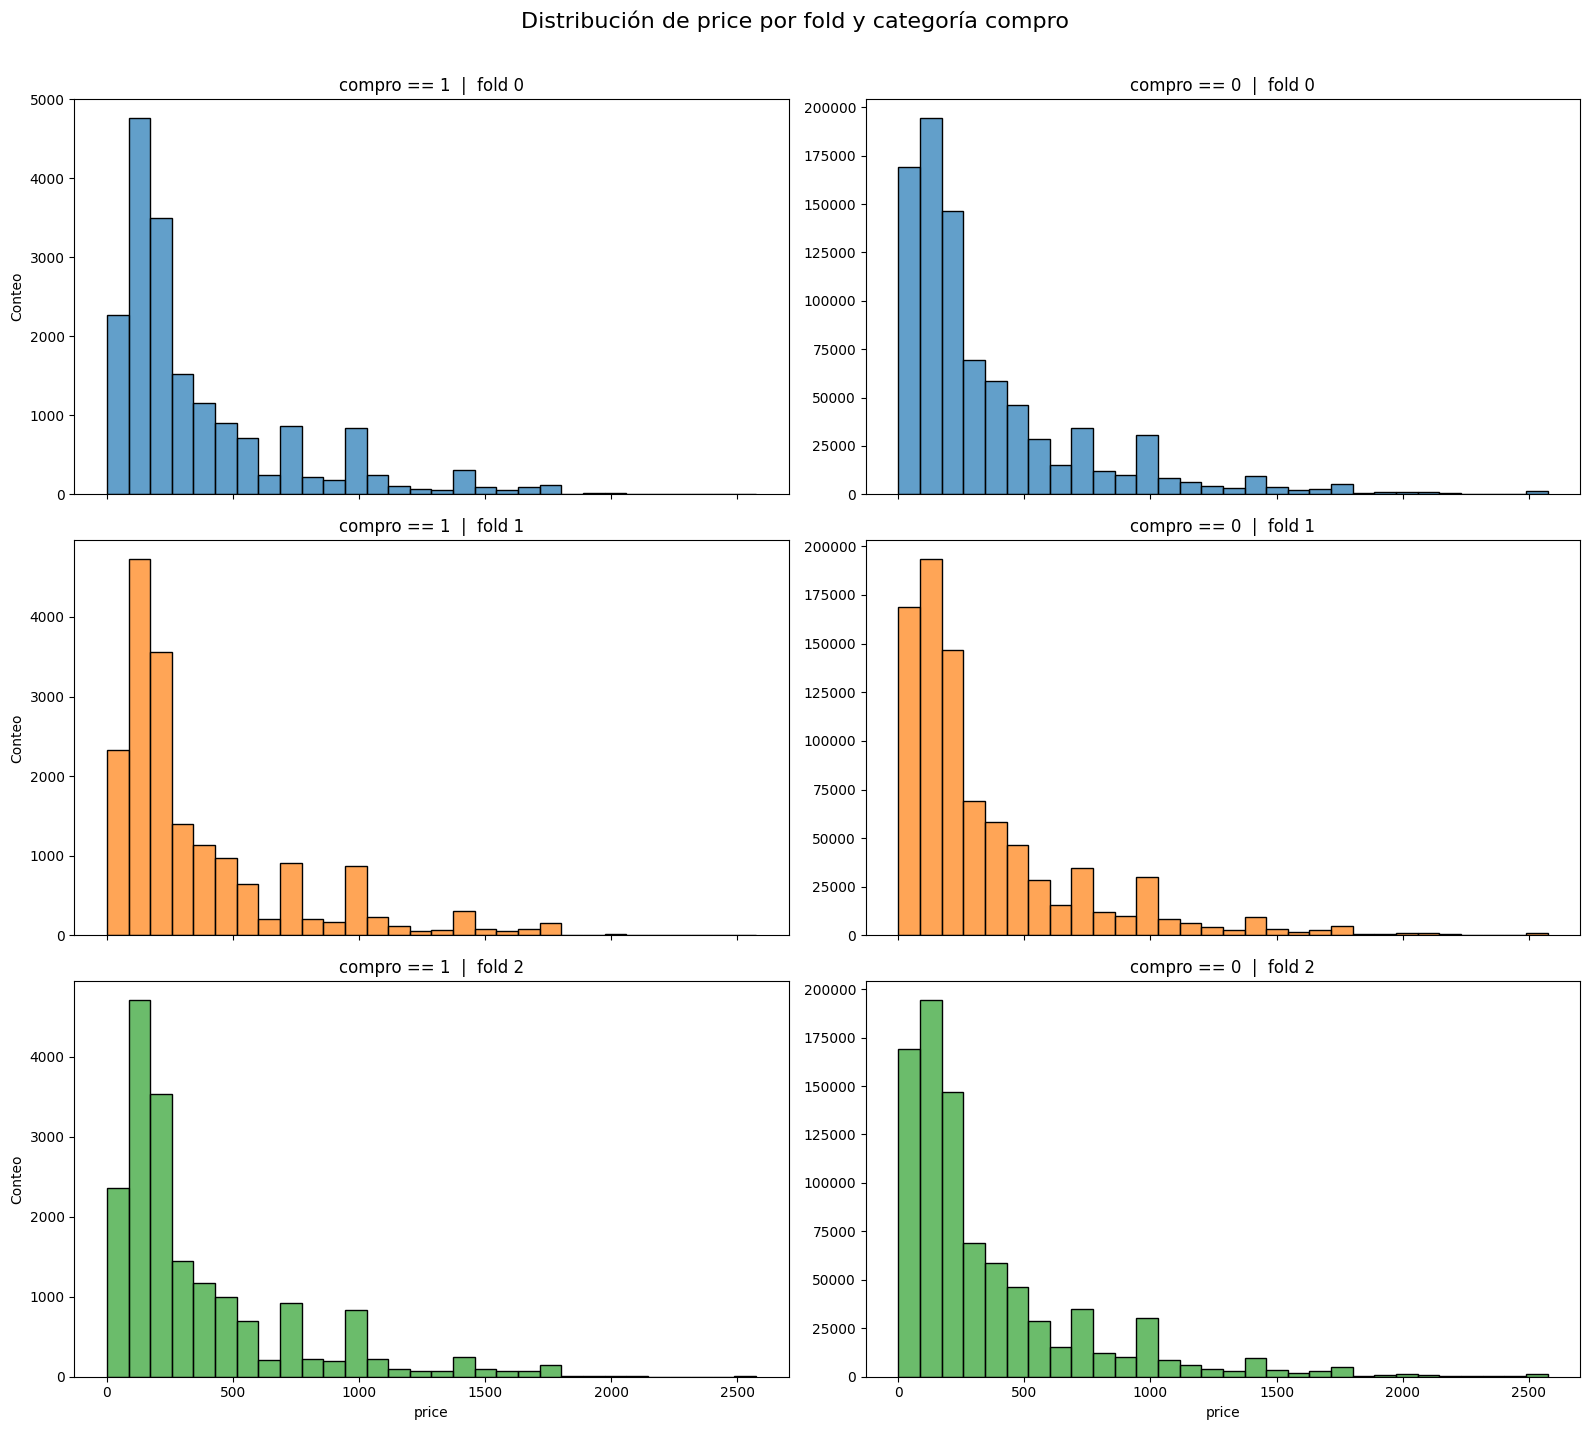

In [54]:
# Histogramas de price por fold, separados por la categoría compro y en un diseño 3x2
pdf_hist = M_folds.select("compro", "price", "fold").toPandas()

fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharex=True, sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
folds = sorted(pdf_hist["fold"].unique())

for i, fold in enumerate(folds):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 1) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_left
    )
    ax_left.set_title(f"compro == 1  |  fold {fold}")
    ax_left.set_xlabel("price")
    ax_left.set_ylabel("Conteo")

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 0) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_right
    )
    ax_right.set_title(f"compro == 0  |  fold {fold}")
    ax_right.set_xlabel("price")
    ax_right.set_ylabel("")

fig.suptitle("Distribución de price por fold y categoría compro", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## 3. Fase de entrenamiento
Para evaluar la calidad y generalización del algoritmo, construiremos un Pipeline con **Árboles de Decisión** (Decision Tree Classifier).

Mediremos el **F1-Score Ponderado** (métrica ideal para Big Data desbalanceado) en cada iteración del bucle. Es vital registrar tanto el rendimiento de Entrenamiento como el de Validación para poder construir posteriormente gráficas que revelen la presencia de sobreajuste (Overfitting).

In [3]:

# 1. Definir transformadores y modelo
cat_idx = StringIndexer(inputCol="category_code_grouped", outputCol="cat_idx", handleInvalid="keep")
brand_idx = StringIndexer(inputCol="brand_grouped", outputCol="brand_idx", handleInvalid="keep")

encoder = OneHotEncoder(inputCols=["cat_idx", "brand_idx"], outputCols=["cat_vec", "brand_vec"])
assembler = VectorAssembler(inputCols=["cat_vec", "brand_vec", "price", "weekhour"], outputCol="features")

# Utilizamos DecisionTree para predecir si el evento será una compra o no
dt = DecisionTreeClassifier(labelCol="compro", featuresCol="features", maxDepth=5, seed=42)

pipeline = Pipeline(stages=[cat_idx, brand_idx, encoder, assembler, dt])
evaluator = MulticlassClassificationEvaluator(labelCol="compro", predictionCol="prediction", metricName="f1")

resultados_cv = []

print(f"--- Iniciando Validación Cruzada ({k}-Folds) ---")
for i in range(k):
    start_time = time.time()
    print(f"\nEntrenando Fold {i+1}...")

    # Separar conjuntos
    train_df = M_folds.filter(col("fold") != i)
    val_df = M_folds.filter(col("fold") == i)

    # Entrenar pipeline
    modelo = pipeline.fit(train_df)

    # Predecir
    pred_train = modelo.transform(train_df)
    pred_val = modelo.transform(val_df)

    # Evaluar métricas
    f1_train = evaluator.evaluate(pred_train)
    f1_val = evaluator.evaluate(pred_val)

    t_ejecucion = time.time() - start_time

    # Guardar resultados
    resultados_cv.append({
        "Fold": f"Fold {i+1}",
        "F1_Train": f1_train,
        "F1_Validation": f1_val,
        "Tiempo(s)": t_ejecucion
    })
    print(f"Completado -> F1 Train: {f1_train:.4f} | F1 Val: {f1_val:.4f} | Tiempo: {t_ejecucion:.1f}s")

# Convertir a Pandas para la sección de visualización
df_resultados = pd.DataFrame(resultados_cv)

--- Iniciando Validación Cruzada (3-Folds) ---

Entrenando Fold 1...
Completado -> F1 Train: 0.9689 | F1 Val: 0.9690 | Tiempo: 119.7s

Entrenando Fold 2...
Completado -> F1 Train: 0.9689 | F1 Val: 0.9690 | Tiempo: 173.6s

Entrenando Fold 3...
Completado -> F1 Train: 0.9690 | F1 Val: 0.9689 | Tiempo: 197.7s


## 4. Visualización de resultados
Haciendo uso de las bibliotecas de visualización `matplotlib` y `seaborn`, transformamos nuestra tabla de métricas en dos gráficos analíticos:
1. **Gráfico de Barras Agrupadas:** Permite contrastar el F1-Score obtenido durante el entrenamiento frente a la validación, fungiendo como detector de sobreajuste.
2. **Gráfico de Cajas (Boxplot):** Nos ayuda a visualizar estadísticamente la dispersión y la variabilidad en la calidad predictiva del modelo ante datos desconocidos.

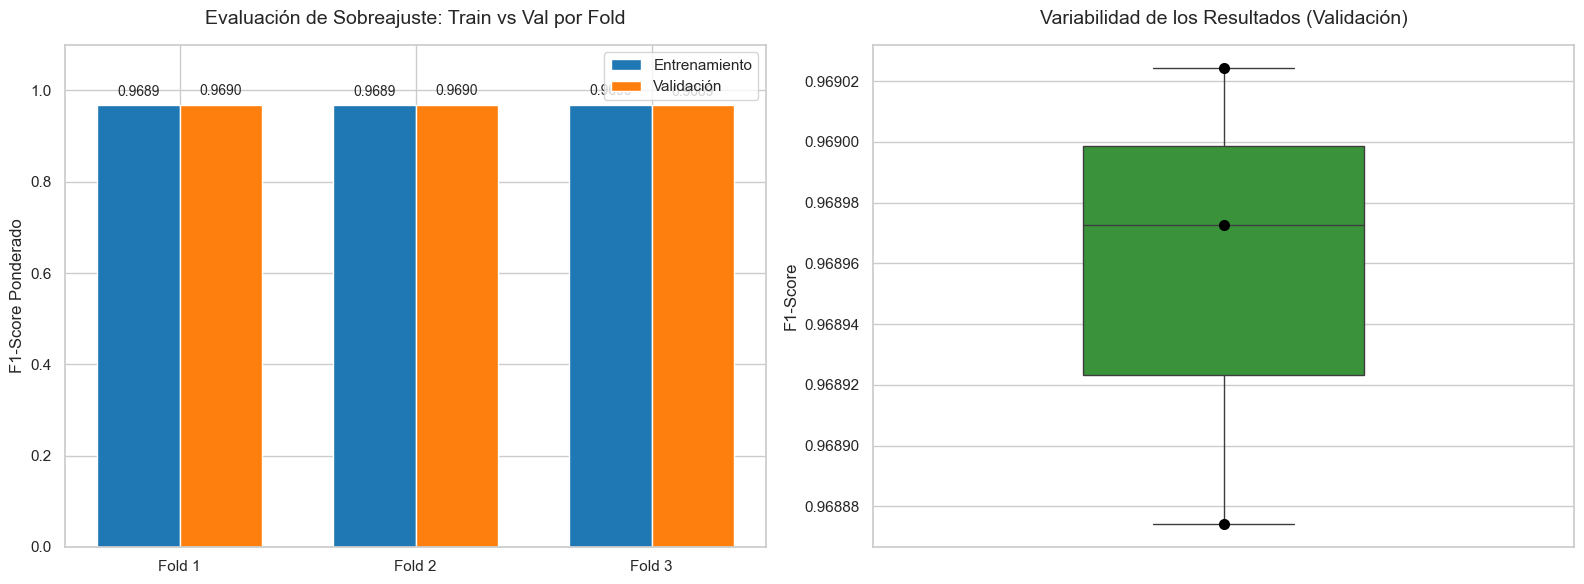


--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---
F1-Score Promedio (Validación): 0.9690
Desviación Estándar (Variabilidad): 0.0001


In [4]:
# ==============================================================================
# GENERACIÓN DE GRÁFICAS ANALÍTICAS (DETECCIÓN DE SOBREAJUSTE Y VARIABILIDAD)
# ==============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Train vs Validation (Overfitting Check) ---
import numpy as np
x = np.arange(len(df_resultados['Fold']))
width = 0.35

axes[0].bar(x - width/2, df_resultados['F1_Train'], width, label='Entrenamiento', color='#1f77b4')
axes[0].bar(x + width/2, df_resultados['F1_Validation'], width, label='Validación', color='#ff7f0e')

axes[0].set_ylabel('F1-Score Ponderado')
axes[0].set_title('Evaluación de Sobreajuste: Train vs Val por Fold', fontsize=14, pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_resultados['Fold'])
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Textos sobre las barras
for i, val in enumerate(df_resultados['F1_Train']):
    axes[0].text(i - width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)
for i, val in enumerate(df_resultados['F1_Validation']):
    axes[0].text(i + width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)

# --- GRÁFICA 2: Boxplot de Variabilidad ---
df_melted = df_resultados.melt(id_vars=['Fold'], value_vars=['F1_Validation'], var_name='Métrica', value_name='F1_Score')

sns.boxplot(y='F1_Score', data=df_melted, ax=axes[1], color='#2ca02c', width=0.4)
sns.swarmplot(y='F1_Score', data=df_melted, ax=axes[1], color='black', size=8)

axes[1].set_title('Variabilidad de los Resultados (Validación)', fontsize=14, pad=15)
axes[1].set_ylabel('F1-Score')

plt.tight_layout()
plt.show()

# Imprimir estadísticas descriptivas
print("\n--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---")
print(f"F1-Score Promedio (Validación): {df_resultados['F1_Validation'].mean():.4f}")
print(f"Desviación Estándar (Variabilidad): {df_resultados['F1_Validation'].std():.4f}")

5.    Discusión de resultados y Conclusiones  

Las bibliotecas de graficación son compatibles con pyspark, de modo que las liberías ejecutadas en cursos anteriores donde se usaba matplotlib o seaborn  son perfectamente compatibles.  Las aplicaciones de tales herramientas gráficas van desde el EDA hasta las visualización de métricas de aprendizaje.

En cuanto a EDA una aplicación muy útil es para las técnicas de muestreo.  Es posible conseguir una "fotografía" de las muestras, y dicha exploración visual es de vital importancia para tener una noción de cómo se deberían ver o comportar los datos en una escala alta.  En otras palabras, existe un universo de datos (población P), virtualmente improcesable, se obtiene una muestra y se hace uso de muestreo incremental para observar el comportamiento típico de la muestra.  Conforme se incrementan tales muestras se observa una convergencia en alguna métrica clave o estadística y es a partir de ahí que se puede conocer una muestra mínima con la capacidad de conseguir la fotografía general de la población.  

En  lo referente a métricas de aprendizaje se puede ver el uso de estrategias k-folds para validaciones cruzadas y se puede evaluar que los sistemas de aprendizaje tengan un comportamiento esperado al momento de cruzar los aprendizajes entre las muestras.  En los 3 folds se pudo observar baja variación en la métrica seleccionada (F1-Score), de modo que dicha estrategia de folds fue apropiada.
